In [101]:
# Data manipulation
import pandas as pd
import numpy as np


# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

# math library
import math
import statistics

# warning management library
import warnings

# DOS like library
import os

# Date management
from datetime import *
from dateutil.relativedelta import *
from dateutil.parser import *


# Images analysis
from PIL import Image
from PIL import ImageOps

# Text Mining
import nltk
nltk.download('punkt')
from wordcloud import WordCloud
from collections import Counter
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('punkt_tab')

# Machine learning
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

# Similarity metrics
from sklearn.metrics.pairwise import cosine_similarity as cossim

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [102]:
warnings.filterwarnings('ignore')
sns.set()
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

### 1. Loading of file title.basics.tz and selecting relevant columns

In [103]:
titles = pd.read_csv("../Raw_Data/title.basics.tsv", sep='\t', nrows = 10000)

In [104]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   tconst          10000 non-null  object
 1   titleType       10000 non-null  object
 2   primaryTitle    10000 non-null  object
 3   originalTitle   10000 non-null  object
 4   isAdult         10000 non-null  int64 
 5   startYear       10000 non-null  object
 6   endYear         10000 non-null  object
 7   runtimeMinutes  10000 non-null  object
 8   genres          10000 non-null  object
dtypes: int64(1), object(8)
memory usage: 703.3+ KB


In [105]:
titles.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short


In [106]:
titles_reduced = titles[["tconst", "primaryTitle", "genres"]]

In [107]:
titles_reduced.head()

,tconst,primaryTitle,genres
0,tt0000001,Carmencita,"Documentary,Short"
1,tt0000002,Le clown et ses chiens,"Animation,Short"
2,tt0000003,Poor Pierrot,"Animation,Comedy,Romance"
3,tt0000004,Un bon bock,"Animation,Short"
4,tt0000005,Blacksmith Scene,Short


In [108]:
titles_reduced.rename(columns={"primaryTitle": "title"}, inplace=True)
titles_reduced["genres"] = titles_reduced["genres"].apply(lambda x: x.replace(",", " "))
titles_reduced.head()

,tconst,title,genres
0,tt0000001,Carmencita,Documentary Short
1,tt0000002,Le clown et ses chiens,Animation Short
2,tt0000003,Poor Pierrot,Animation Comedy Romance
3,tt0000004,Un bon bock,Animation Short
4,tt0000005,Blacksmith Scene,Short


### 2. Starting Natural Language Processing

#### 2.1 Lemmatization and Tokenization functions

In [109]:
# list of french stopwords : https://www.ranks.nl/stopwords/french
french_stopwords = ["alors","au","aucun","aussi","autre","avant","avec","avoir","bon","car","ce","cela","ces","ceux","chaque","ci",
                    "comme","comment","dans","des","du",
"dedans","dehors","depuis","devrait","doit","donc","début", "de","elle","elles","en","encore","essai","est","et","eu","fait","faites",
"fois","font","hors","ici","il","ils","je","juste",
"la","le","les","leur","là","ma","maintenant","mais","mes","mien","moins","mon","mot","même","ni","notre","nous","ou","où","par",
"parce","pas","peut","peu","plupart","pour","pourquoi",
"quand","que","quel","quelle","quelles","quels","qui","sa","sans","ses","seulement","si","sien","son","sont","sous","soyez","sur",
"ta","tandis","tellement","tels","tes","ton","tous",
"tout","trop","très","tu","voient","vont","votre","vous","vu","ça","étaient","état","étions","été","être", "un"]

In [110]:
# creating a list of stopwords for a specific text : with text most common words, and with french end english typical stopwords list
def stopwords_list(text,sw_nb):
    # Lemmatization
    text=text.lower()
    lemmatizer = WordNetLemmatizer()
    text=lemmatizer.lemmatize(text)
    
    # Tokenization
    words_list=nltk.word_tokenize(text)
    words_list= [word for word in words_list if word.isalnum()]
    
    # Suppress digits
    words_list=[w for w in words_list if w.isalpha()]
    
    # wordcount and stopwords
    word_counts = Counter(words_list)
    stopwords_list=[count[0] for count in word_counts.most_common(sw_nb)]
    
    sw = set()
    sw.update(stopwords_list)
    sw.update(tuple(nltk.corpus.stopwords.words('english')))
    sw=list(sw)
    # adding french stopwords
    for fsw in french_stopwords:
        sw.append(fsw)
    return sw

In [111]:
# Text lemmatization and tokenization
def tokenize_text(text):
    # Lemmatization
    text=text.lower()
    lemmatizer = WordNetLemmatizer()
    text=lemmatizer.lemmatize(text)
    
    # Tokenization
    words_list=nltk.word_tokenize(text)
    words_list= [word for word in words_list if word.isalnum()]
    
    # Suppress digits
    words_list=[lemmatizer.lemmatize(w) for w in words_list if w.isalpha()]
    return words_list

In [112]:
# definition of a wordcloud function to have a small visualisation
def word_cloud(words_list):
    wordcloud=WordCloud()
    sentence=' '.join(words_list)
    wordcloud.generate(sentence)
    # create a figure
    fig, ax = plt.subplots(1,1, figsize = (9,6))
    # add interpolation = bilinear to smooth things out
    plt.imshow(wordcloud, interpolation='bilinear')
    # and remove the axis
    plt.axis("off")

#### 2.2 Text pre-processing

In [113]:
text = (titles_reduced.iloc[:,1] + " ").sum()

In [114]:
text

"Carmencita Le clown et ses chiens Poor Pierrot Un bon bock Blacksmith Scene Chinese Opium Den Corbett and Courtney Before the Kinetograph Edison Kinetoscopic Record of a Sneeze Miss Jerry Leaving the Factory Akrobatisches Potpourri The Arrival of a Train The Photographical Congress Arrives in Lyon The Waterer Watered Around a Cabin Boat Leaving the Port Italienischer Bauerntanz Das boxende Känguruh The Clown Barber The Derby 1895 Blacksmith Scene The Sea Opening of the Kiel Canal The Oxford and Cambridge University Boat Race The Messers. Lumière at Cards Cordeliers' Square in Lyon Fishing for Goldfish Baby's Meal Rough Sea at Dover Jumping the Blanket Die Serpentintänzerin Horse Trick Riders Arrivée d'un train gare de Vincennes Watering the Flowers Awakening of Rip Sea Bathing The Ball Game Barnet Horse Fair Barque sortant du port de Trouville Bataille de neige Bateau-mouche sur la Seine Batteuse à vapeur Le bivouac Les blanchisseuses Bois de Boulogne Boulevard des Italiens The Boxing

In [115]:
sw=stopwords_list(text,10)

In [116]:
sw[:20]

['ourselves',
 'and',
 'herself',
 "they're",
 'did',
 "we'll",
 'your',
 'will',
 "we've",
 'didn',
 'needn',
 "he's",
 'against',
 'both',
 "he'd",
 "she'll",
 'has',
 'himself',
 'her',
 'am']

In [117]:
text = (titles_reduced.iloc[:,1] + " " + titles_reduced.iloc[:,2] + " ").sum()
words_list = tokenize_text(text)

In [118]:
words_list_wo_sw=[w for w in words_list if w not in sw]

In [119]:
words_list_wo_sw[:20]

['carmencita',
 'documentary',
 'short',
 'clown',
 'chiens',
 'animation',
 'short',
 'poor',
 'pierrot',
 'animation',
 'comedy',
 'romance',
 'bock',
 'animation',
 'short',
 'blacksmith',
 'scene',
 'short',
 'chinese',
 'opium']

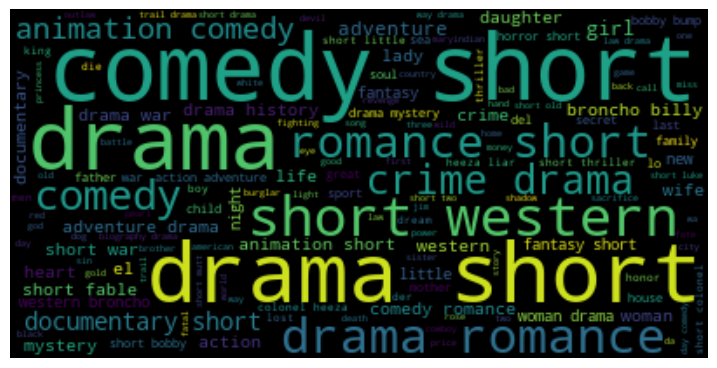

In [120]:
word_cloud(words_list_wo_sw)

#### 2.3 TF-IDF

In [121]:
tfidf = TfidfVectorizer(tokenizer=tokenize_text,stop_words=sw)

In [122]:
words_tfidf = tfidf.fit_transform((titles_reduced.iloc[:,1] + " " + titles_reduced.iloc[:,2] + " "))

In [123]:
words_tfidf.shape

(10000, 7581)

### 3. Recommandations using different metrics 

#### 3.1 Cosine similarity

In [124]:
cossim_matrix = cossim(words_tfidf,words_tfidf)

In [125]:
cossim_matrix.shape

(10000, 10000)

<Axes: >

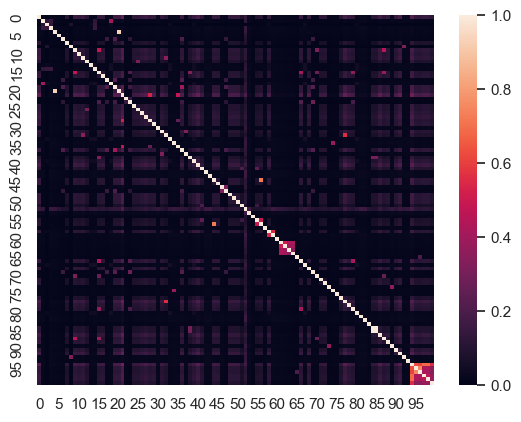

In [127]:
sns.heatmap(cossim_matrix[:100, :100])

In [ ]:
# generate serie with the index of each movie
indices = pd.Series(titles_reduced.index, index=titles_reduced['title'].apply(lambda x: x.lower())) #.drop_duplicates()

In [134]:
indices[:10]

title
carmencita                                     0
le clown et ses chiens                         1
poor pierrot                                   2
un bon bock                                    3
blacksmith scene                               4
chinese opium den                              5
corbett and courtney before the kinetograph    6
edison kinetoscopic record of a sneeze         7
miss jerry                                     8
leaving the factory                            9
dtype: int64

In [136]:
def get_reco(title, cosine_sim=cossim_matrix):
    # Get the index of the movie that matches the title
    title = title.lower()
    idx = indices[title]

    # Get the pairwsie similarity scores of all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the movies based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar movies
    sim_scores = sim_scores[1:11]

    # Get the movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar movies
    return titles_reduced['title'].iloc[movie_indices]

In [138]:
# recommandation for the first movie
print("first movie title: "+titles_reduced['title'].iloc[0])
get_reco(titles_reduced['title'].iloc[0])

first movie title: Carmencita


21                         The Sea
94            Place Saint-Augustin
9863                         China
9625                     St. Croix
40      Bateau-mouche sur la Seine
77            La gare Saint-Lazare
9773              Before Breakfast
9518                     The Storm
4718          The War of the World
91                       Melbourne
Name: title, dtype: object